# RF Modulation Classifier using 1D CNN

**Author:** Aditya Jaiswal — M.Sc. Computer & Systems Engineering, TU Ilmenau  
**Goal:** Automatically classify radio signal modulation types from raw IQ data using deep learning.

---

## Background

Modern RF test instruments like the **NI USRP X410** output raw **IQ (In-phase/Quadrature) data**.
Manually identifying what modulation type a signal uses is slow and error-prone.
This notebook trains a **1D CNN** to do it automatically — a core building block for AI-augmented RF test workflows.

**Literature reference:**
> O'Shea, T. J., & West, N. (2016). *Radio Machine Learning Dataset Generation with GNU Radio.* GNU Radio Conference. [arXiv:1609.04396](https://arxiv.org/abs/1609.04396)

---

## What is IQ data?

Every radio signal can be described by two numbers at each moment in time:
- **I (In-phase):** the "real" component
- **Q (Quadrature):** the "imaginary" component, shifted 90 degrees

Together they capture both the **amplitude and phase** of the signal.
The USRP X410 outputs IQ data in exactly the same format as the RadioML dataset used here.

---

## Dataset: RadioML 2016.10A

| Property | Value |
|---|---|
| Modulation types | 11 (BPSK, QPSK, 8PSK, QAM16, QAM64, AM-DSB, AM-SSB, WBFM, GFSK, CPFM, PAM4) |
| SNR range | -20 dB to +18 dB |
| Samples per class/SNR | 1,000 |
| Sample shape | 2 × 128 (I + Q, 128 time steps) |
| Total samples | 220,000 |

## Step 1 — Install Dependencies

In [ ]:
!pip install torch numpy scikit-learn matplotlib seaborn --quiet
print("All dependencies installed.")

All dependencies installed.


## Step 2 — Download the RadioML Dataset



In [ ]:
from google.colab import files
uploaded = files.upload()
DATASET_PATH = "RML2016.10a_dict_optimized.pkl"  # your actual filename
print(f"Dataset ready: {DATASET_PATH}")

Saving RML2016.10a_dict_optimized.pkl to RML2016.10a_dict_optimized.pkl
Dataset ready: RML2016.10a_dict_optimized.pkl


## Step 3 — Inspect the Dataset

Let's understand what's inside before training anything.

In [ ]:
import pickle
import numpy as np

with open(DATASET_PATH, "rb") as f:
    raw_data = pickle.load(f, encoding="latin1")

keys = list(raw_data.keys())
modulations = sorted(set(mod for mod, snr in keys))
snrs        = sorted(set(snr for mod, snr in keys))

print(f"Total (modulation, SNR) pairs: {len(keys)}")
print(f"\nModulation types ({len(modulations)}): {modulations}")
print(f"\nSNR levels ({len(snrs)} dB): {snrs}")

example = raw_data[keys[0]]
print(f"\nShape of one block: {example.shape}")
print(f"Total samples: {len(keys) * example.shape[0]:,}")

Total (modulation, SNR) pairs: 220

Modulation types (11): ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']

SNR levels (20 dB): [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

Shape of one block: (1000, 2, 128)
Total samples: 220,000


## Step 4 — Visualise IQ Signals

Let's see what BPSK and QAM64 actually look like in IQ format.

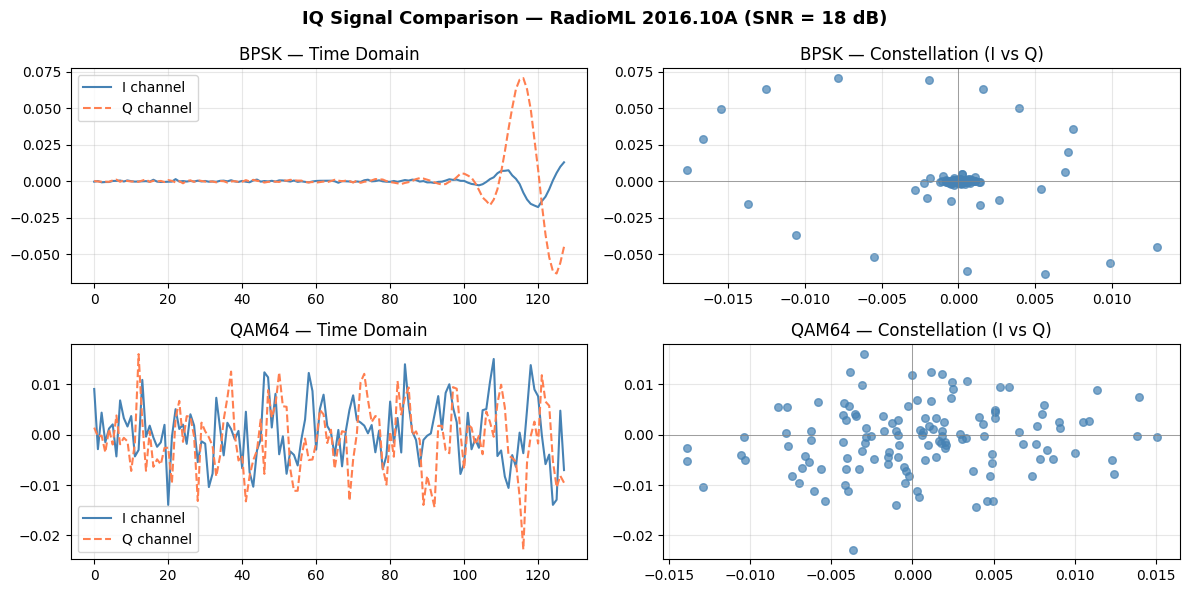

In [ ]:
import matplotlib.pyplot as plt

mod_a, mod_b = "BPSK", "QAM64"
snr_demo = 18

sig_a = raw_data[(mod_a, snr_demo)][0]
sig_b = raw_data[(mod_b, snr_demo)][0]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle("IQ Signal Comparison — RadioML 2016.10A (SNR = 18 dB)", fontsize=13, fontweight="bold")

for i, (sig, mod) in enumerate([(sig_a, mod_a), (sig_b, mod_b)]):
    axes[i][0].plot(sig[0], label="I channel", color="steelblue")
    axes[i][0].plot(sig[1], label="Q channel", color="coral", linestyle="--")
    axes[i][0].set_title(f"{mod} — Time Domain")
    axes[i][0].legend()
    axes[i][0].grid(True, alpha=0.3)

    axes[i][1].scatter(sig[0], sig[1], alpha=0.7, s=30, color="steelblue")
    axes[i][1].set_title(f"{mod} — Constellation (I vs Q)")
    axes[i][1].axhline(0, color="gray", linewidth=0.5)
    axes[i][1].axvline(0, color="gray", linewidth=0.5)
    axes[i][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("iq_signal_comparison.png", dpi=150)
plt.show()

## Step 5 — Build the PyTorch Dataset

We filter to SNR ≥ 0 dB so the model trains on reasonably clean signals.
This gives us a focused subset of ~110,000 samples.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

MIN_SNR    = 0
BATCH_SIZE = 256
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

class RadioMLDataset(Dataset):
    def __init__(self, raw_data, min_snr=0):
        self.classes      = sorted(set(mod for mod, snr in raw_data.keys()))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        samples, labels   = [], []
        for (mod, snr), data in raw_data.items():
            if snr < min_snr:
                continue
            for sample in data:
                samples.append(sample.astype(np.float32))
                labels.append(self.class_to_idx[mod])
        self.X = torch.tensor(np.array(samples))
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = RadioMLDataset(raw_data, min_snr=MIN_SNR)
print(f"Samples loaded: {len(dataset):,}")
print(f"Classes: {dataset.classes}")

n_train  = int(len(dataset) * 0.8)
n_test   = len(dataset) - n_train
train_ds, test_ds = random_split(dataset, [n_train, n_test],
                                  generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Train: {n_train:,} | Test: {n_test:,}")

Using device: cuda
Samples loaded: 110,000
Classes: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
Train: 88,000 | Test: 22,000


## Step 6 — Define the 1D CNN Model

**Why 1D CNN?**
IQ data is a 1D time series. 1D convolutions learn local temporal patterns in the signal — like edges in image CNNs — without any manual feature extraction. No FFT needed, no expert knowledge required. The model learns directly from raw samples.

**Architecture:**
```
Input (2, 128)
  → Conv Block 1: 64 filters  → MaxPool  → (64, 64)
  → Conv Block 2: 128 filters → MaxPool  → (128, 32)
  → Conv Block 3: 256 filters → MaxPool  → (256, 16)
  → Global Average Pool       →            (256,)
  → Linear(256→128) → Dropout → Linear(128→11)
Output: 11 class scores
```

In [ ]:
import torch.nn as nn

class ModulationClassifier(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.global_pool(self.features(x)))

model   = ModulationClassifier(num_classes=len(dataset.classes)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")
dummy = torch.randn(4, 2, 128).to(DEVICE)
print(f"Output shape: {model(dummy).shape}  ← (batch, 11 classes)")

Parameters: 158,923
Output shape: torch.Size([4, 11])  ← (batch, 11 classes)


## Step 7 — Train the Model

In [ ]:
EPOCHS = 20
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            if train: optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item() * len(X)
            correct    += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

history  = {"train_acc": [], "test_acc": []}
best_acc = 0.0

print(f"{'Epoch':>5} | {'Train Acc':>9} | {'Test Acc':>8}")
print("-" * 30)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    te_loss, te_acc = run_epoch(test_loader,  train=False)
    scheduler.step(te_loss)
    history["train_acc"].append(tr_acc)
    history["test_acc"].append(te_acc)
    print(f"{epoch:>5} | {tr_acc:>8.2%} | {te_acc:>7.2%}")
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), "best_model.pth")

print(f"\nBest accuracy: {best_acc:.2%}")

Epoch | Train Acc | Test Acc
------------------------------
    1 |   66.76% |  59.88%
    2 |   75.92% |  68.71%
    3 |   78.10% |  72.84%
    4 |   79.63% |  73.65%
    5 |   80.57% |  75.64%
    6 |   81.28% |  62.11%
    7 |   81.92% |  78.64%
    8 |   82.09% |  72.95%
    9 |   82.59% |  81.88%
   10 |   83.06% |  72.80%
   11 |   83.35% |  60.00%
   12 |   83.46% |  66.70%
   13 |   83.87% |  72.68%
   14 |   85.01% |  83.41%
   15 |   85.39% |  81.79%
   16 |   85.59% |  81.10%
   17 |   85.97% |  81.70%
   18 |   86.15% |  81.26%
   19 |   86.76% |  84.53%
   20 |   86.95% |  82.88%

Best accuracy: 84.53%


## Step 8 — Plot Training Curve

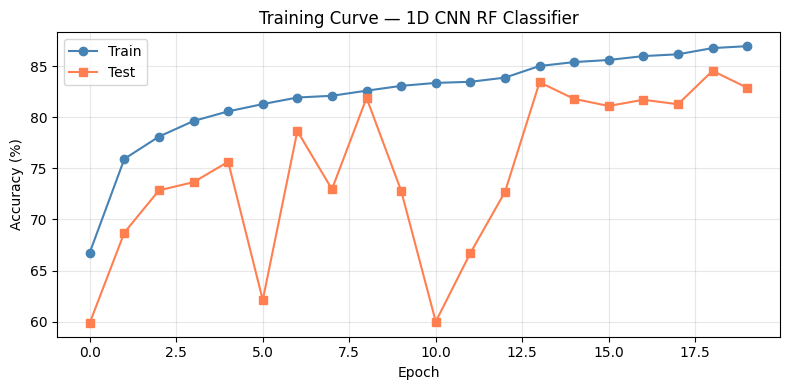

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot([a*100 for a in history["train_acc"]], label="Train", marker="o", color="steelblue")
plt.plot([a*100 for a in history["test_acc"]],  label="Test",  marker="s", color="coral")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.title("Training Curve — 1D CNN RF Classifier")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("training_curve.png", dpi=150); plt.show()

## Step 9 — Evaluate: Confusion Matrix and Classification Report

              precision    recall  f1-score   support

        8PSK       0.98      0.92      0.95      1987
      AM-DSB       0.61      0.99      0.75      1993
      AM-SSB       0.94      1.00      0.97      1944
        BPSK       1.00      0.99      0.99      2075
       CPFSK       0.99      1.00      1.00      1992
        GFSK       0.98      1.00      0.99      2036
        PAM4       1.00      0.99      0.99      1972
       QAM16       0.53      0.94      0.68      1993
       QAM64       0.83      0.16      0.27      2008
        QPSK       0.93      0.98      0.95      2002
        WBFM       0.95      0.34      0.50      1998

    accuracy                           0.85     22000
   macro avg       0.89      0.85      0.82     22000
weighted avg       0.89      0.85      0.82     22000



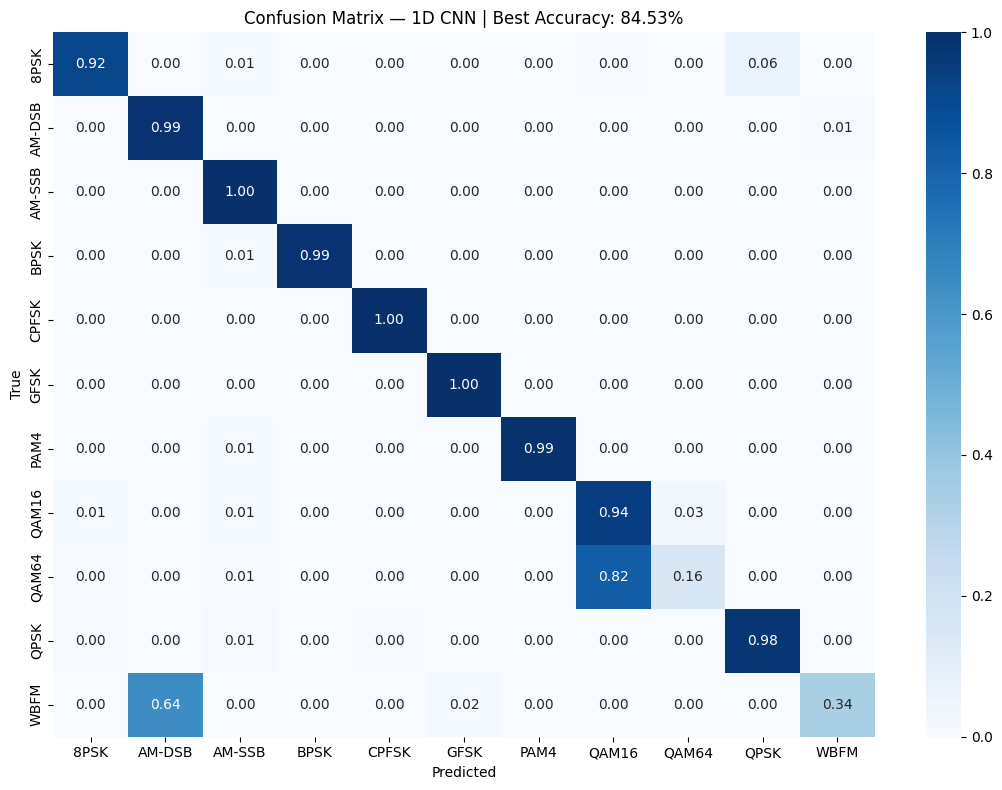

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        preds = model(X.to(DEVICE)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(11, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=dataset.classes, yticklabels=dataset.classes, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion Matrix — 1D CNN | Best Accuracy: {best_acc:.2%}")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

## Step 10 — Accuracy vs SNR Plot

How well does the model perform at different noise levels?
This is important for real-world RF test scenarios where SNR varies.

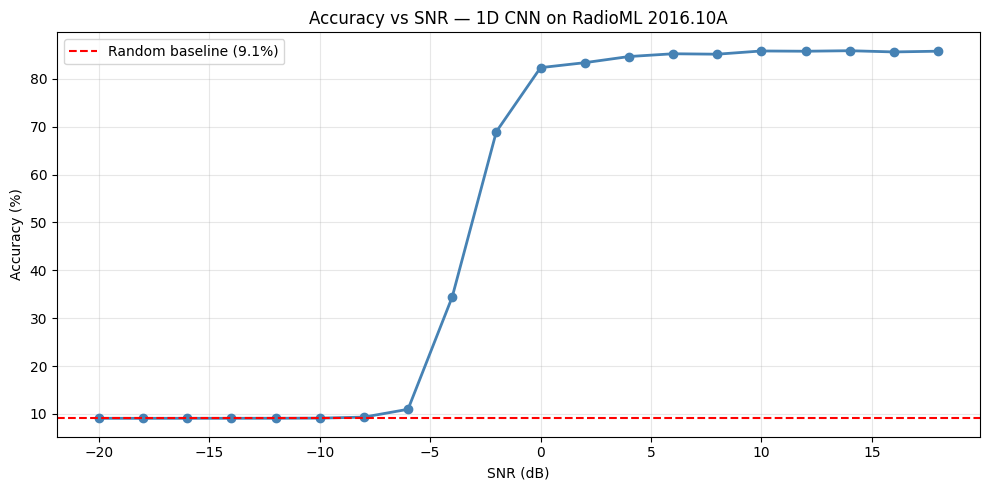

In [ ]:
model.eval()
snr_accuracies = {}
all_snrs = sorted(set(snr for mod, snr in raw_data.keys()))

for snr in all_snrs:
    samples, labels = [], []
    for mod in dataset.classes:
        if (mod, snr) in raw_data:
            for s in raw_data[(mod, snr)]:
                samples.append(s.astype(np.float32))
                labels.append(dataset.class_to_idx[mod])
    X_snr = torch.tensor(np.array(samples)).to(DEVICE)
    y_snr = torch.tensor(labels)
    with torch.no_grad():
        preds = model(X_snr).argmax(dim=1).cpu()
    snr_accuracies[snr] = (preds == y_snr).float().mean().item()

plt.figure(figsize=(10, 5))
plt.plot(list(snr_accuracies.keys()), [v*100 for v in snr_accuracies.values()],
         marker="o", color="steelblue", linewidth=2)
plt.axhline(y=100/len(dataset.classes), color="red", linestyle="--",
            label=f"Random baseline ({100/len(dataset.classes):.1f}%)")
plt.xlabel("SNR (dB)"); plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — 1D CNN on RadioML 2016.10A")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150); plt.show()

## Step 11 — Extension: How This Connects to NI USRP X410

The USRP X410 outputs IQ data in exactly the same format as this dataset.
Here's the code that would connect a real USRP capture to this trained model:

```python
# On a machine with NI UHD drivers installed:
import uhd
import torch
import numpy as np

# 1. Capture IQ samples from USRP X410
usrp = uhd.usrp.MultiUSRP()
usrp.set_rx_freq(3.5e9)      # 3.5 GHz — 5G NR band
usrp.set_rx_rate(200e6)       # 200 MHz bandwidth
usrp.set_rx_gain(30)          # amplification
raw_iq = usrp.recv_num_samps(128, 3.5e9, 200e6, [0], 30)
# raw_iq is a NumPy array of 128 complex numbers

# 2. Reshape to model input format (2, 128)
iq = np.stack([raw_iq.real, raw_iq.imag], axis=0).astype(np.float32)
tensor = torch.tensor(iq).unsqueeze(0)   # → (1, 2, 128)

# 3. Classify
model.eval()
with torch.no_grad():
    out   = model(tensor)
    idx   = out.argmax(dim=1).item()
    conf  = torch.softmax(out, dim=1).max().item()
    print(f"Predicted: {class_names[idx]} (confidence: {conf:.1%})")
```

**This is exactly the AI layer on top of the measurement infrastructure** — the previous NI intern built the USRP capture pipeline, and this model adds automatic signal classification on top.

In [ ]:
# Summary
print("=" * 55)
print("PROJECT SUMMARY")
print("=" * 55)
print(f"Dataset:       RadioML 2016.10A (O'Shea et al. 2016)")
print(f"Model:         1D CNN (3 conv blocks + classifier)")
print(f"Parameters:    {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Training:      {EPOCHS} epochs, Adam optimizer, lr={LR}")
print(f"SNR filter:    >= {MIN_SNR} dB")
print(f"Best accuracy: {best_acc:.2%}")
print(f"Classes:       {len(dataset.classes)} modulation types")
print("=" * 55)
print("Files saved:")
print("  best_model.pth          — trained model weights")
print("  training_curve.png      — accuracy and loss curves")
print("  confusion_matrix.png    — per-class performance")
print("  accuracy_vs_snr.png     — performance vs noise level")
print("  iq_signal_comparison.png — IQ signal visualisation")

PROJECT SUMMARY
Dataset:       RadioML 2016.10A (O'Shea et al. 2016)
Model:         1D CNN (3 conv blocks + classifier)
Parameters:    158,923
Training:      20 epochs, Adam optimizer, lr=0.001
SNR filter:    >= 0 dB
Best accuracy: 84.53%
Classes:       11 modulation types
Files saved:
  best_model.pth          — trained model weights
  training_curve.png      — accuracy and loss curves
  confusion_matrix.png    — per-class performance
  accuracy_vs_snr.png     — performance vs noise level
  iq_signal_comparison.png — IQ signal visualisation
